<a href="https://colab.research.google.com/github/mmallare/ECGR4106/blob/main/ecgr4106_homework4a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import train_test_split
import requests
from torch.utils.data import Dataset, DataLoader
import time
import math
import matplotlib.pyplot as plt
import random
import re
import matplotlib.ticker as ticker
import torch.nn.functional as F
from nltk.translate.bleu_score import SmoothingFunction, sentence_bleu
from torch.utils.data import DataLoader, Dataset
import sys
import subprocess
import copy

try:
    import nltk
except ImportError:
    print("NLTK library not found. Installing it now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "nltk"])
    import nltk


url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)
text = response.text
# print(text)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

Using device: cuda


In [ ]:
class PositionalEncoding(nn.Module):
    """Standard sinusoidal positional encoding (same as in the course examples)."""

    def __init__(self, d_model, max_len=5000):
        super().__init__()
        encoding = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        encoding[:, 0::2] = torch.sin(position * div_term)
        encoding[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("encoding", encoding.unsqueeze(0))

    def forward(self, x):
        return x + self.encoding[:, : x.size(1)].detach()


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_size_kb(model):
    return count_parameters(model) * 4 / 1024

In [ ]:
TEXT = (
    "Next character prediction is a fundamental task in the field of natural language processing (NLP) "
    "that involves predicting the next character in a sequence of text based on the characters that precede it. "
    "This task is essential for various applications, including text auto-completion, spell checking, and even "
    "in the development of sophisticated AI models capable of generating human-like text. "
    "At its core, next character prediction relies on statistical models or deep learning algorithms to analyze "
    "a given sequence of text and predict which character is most likely to follow. "
    "These predictions are based on patterns and relationships learned from large datasets of text during the "
    "training phase of the model. "
    "One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks "
    "(RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. "
    "RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' "
    "about previous characters to inform the prediction of the next character. "
    "LSTM networks enhance this capability by being able to remember long-term dependencies, making them even "
    "more effective for next character prediction tasks. "
    "Training a model for next character prediction involves feeding it large amounts of text data, allowing it "
    "to learn the probability of each character's appearance following a sequence of characters. "
    "During this training process, the model adjusts its parameters to minimize the difference between its "
    "predictions and the actual outcomes, thus improving its predictive accuracy over time. "
    "Once trained, the model can be used to predict the next character in a given piece of text by considering "
    "the sequence of characters that precede it. "
    "This can enhance user experience in text editing software, improve efficiency in coding environments with "
    "auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants. "
    "In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP "
    "applications, making text-based interactions more efficient, accurate, and human-like. "
    "Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues "
    "to evolve, opening new possibilities for the future of text-based technology."
)

chars = sorted(list(set(TEXT)))
vocab_size = len(chars)
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}
encoded_text = [char_to_int[ch] for ch in TEXT]

print(f"Text length : {len(TEXT)} characters")
print(f"Vocabulary  : {vocab_size} unique characters")


# %%
class CharDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index], self.targets[index]


def make_loaders(encoded, sequence_length, batch_size=128, val_fraction=0.2, seed=RANDOM_SEED):
    """Windowed next-char dataset -> 80/20 split (matches HW2's make_loaders)."""
    sequences, targets = [], []
    for i in range(len(encoded) - sequence_length):
        sequences.append(encoded[i: i + sequence_length])
        targets.append(encoded[i + sequence_length])

    sequences = torch.tensor(sequences, dtype=torch.long)
    targets = torch.tensor(targets, dtype=torch.long)

    dataset = CharDataset(sequences, targets)
    train_size = int(len(dataset) * (1 - val_fraction))
    test_size = len(dataset) - train_size
    gen = torch.Generator().manual_seed(seed)
    train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size], generator=gen)
    train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)
    return train_loader, test_loader


# RNN baselines
class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.rnn(embedded)
        return self.fc(output[:, -1, :])


class CharLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.rnn = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.rnn(embedded)
        return self.fc(output[:, -1, :])


class CharGRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.rnn = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.rnn(embedded)
        return self.fc(output[:, -1, :])


def build_rnn_model(model_type, vocab_size, hidden_size=128):
    if model_type == "RNN":
        return CharRNN(vocab_size, hidden_size, vocab_size)
    elif model_type == "LSTM":
        return CharLSTM(vocab_size, hidden_size, vocab_size)
    elif model_type == "GRU":
        return CharGRU(vocab_size, hidden_size, vocab_size)
    raise ValueError(model_type)


class CharTransformer(nn.Module):
    def __init__(self, vocab_size, hidden_size, n_layers, n_heads, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.pos_encoder = PositionalEncoding(hidden_size)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size, nhead=n_heads, batch_first=True, dropout=dropout
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        embedded = self.pos_encoder(self.embedding(x))
        output = self.transformer_encoder(embedded)
        return self.fc(output[:, -1, :])


# train / eval loops
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            output = model(x)
            loss = criterion(output, y)
            total_loss += loss.item()
            _, predicted = torch.max(output, 1)
            correct += (predicted == y).sum().item()
            total += y.size(0)
    return total_loss / len(loader), correct / total


def train_char_model(model, model_name, encoded, seq_len, epochs=300, lr=0.005, batch_size=128,
                      log_every=10, patience=15):
    """`epochs` is now a CAP, not a fixed count: training stops early once
    validation loss hasn't improved for `patience` consecutive epochs, and
    also stops (naturally) if the cap is reached first."""
    print(f"\n=== {model_name} | seq_len={seq_len} (max_epochs={epochs}, patience={patience}) ===")
    train_loader, test_loader = make_loaders(encoded, seq_len, batch_size)
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses, val_accs = [], [], []

    best_val_loss = float("inf")
    best_epoch, best_train_loss, best_val_acc_at_best_epoch = 0, None, None
    best_state_dict = None
    best_val_acc, best_acc_epoch = -1.0, 0
    epochs_since_improvement = 0
    stopped_early = False

    t0 = time.time()
    final_epoch = 0
    for epoch in range(1, epochs + 1):
        final_epoch = epoch
        tr_loss = train_epoch(model, train_loader, optimizer, criterion)
        v_loss, v_acc = evaluate(model, test_loader, criterion)
        train_losses.append(tr_loss)
        val_losses.append(v_loss)
        val_accs.append(v_acc)

        if v_loss < best_val_loss:
            best_val_loss = v_loss
            best_epoch = epoch
            best_train_loss = tr_loss
            best_val_acc_at_best_epoch = v_acc
            best_state_dict = copy.deepcopy(model.state_dict())
            epochs_since_improvement = 0
        else:
            epochs_since_improvement += 1

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_acc_epoch = epoch

        if epoch % log_every == 0:
            print(f"Epoch {epoch}, Loss: {tr_loss:.4f}, Validation Loss: {v_loss:.4f}, Validation Accuracy: {v_acc:.4f}")

        if epochs_since_improvement >= patience:
            stopped_early = True
            print(f"Early stopping at epoch {epoch}: no validation-loss improvement for {patience} epochs "
                  f"(best epoch so far: {best_epoch}).")
            break
    elapsed = time.time() - t0

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    n_params = count_parameters(model)
    size_kb = model_size_kb(model)
    print(f"Best epoch: {best_epoch}/{final_epoch}{' (early-stopped)' if stopped_early else ''} | "
          f"Train Loss: {best_train_loss:.4f} | "
          f"Val Loss: {best_val_loss:.4f} | Val Acc @ best epoch: {best_val_acc_at_best_epoch:.4f} | "
          f"Best Val Acc (any epoch {best_acc_epoch}): {best_val_acc:.4f}")
    print(f"Time: {elapsed:.1f}s | Params: {n_params:,} | Size: {size_kb:.1f} KB")

    return {
        "model_name": model_name,
        "seq_len": seq_len,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accs": val_accs,
        "best_epoch": best_epoch,
        "epochs_run": final_epoch,
        "stopped_early": stopped_early,
        "best_train_loss": best_train_loss,
        "best_val_loss": best_val_loss,
        "best_val_acc": best_val_acc_at_best_epoch,
        "best_val_acc_any_epoch": best_val_acc,
        "best_acc_epoch": best_acc_epoch,
        "train_time_s": elapsed,
        "n_params": n_params,
        "size_kb": size_kb,
        "model": model,
    }

Text length : 2386 characters
Vocabulary  : 44 unique characters


In [ ]:
SEQ_LENGTHS_P1 = [10, 20, 30]
RNN_TYPES_P1 = ["RNN", "LSTM", "GRU"]
EPOCHS_P1 = 300
TRANSFORMER_HIDDEN = 128
TRANSFORMER_LAYERS_DEFAULT = 2
TRANSFORMER_HEADS_DEFAULT = 2

problem1_results = []
for seq_len in SEQ_LENGTHS_P1:
    for mtype in RNN_TYPES_P1:
        model = build_rnn_model(mtype, vocab_size, hidden_size=TRANSFORMER_HIDDEN)
        r = train_char_model(model, mtype, encoded_text, seq_len, epochs=EPOCHS_P1)
        problem1_results.append(r)

    transformer_model = CharTransformer(
        vocab_size, TRANSFORMER_HIDDEN, TRANSFORMER_LAYERS_DEFAULT, TRANSFORMER_HEADS_DEFAULT
    )
    r = train_char_model(
        transformer_model, "Transformer", encoded_text, seq_len, epochs=EPOCHS_P1, lr=0.001
    )
    problem1_results.append(r)

print("\nProblem 1 sweep complete.")


=== RNN | seq_len=10 (max_epochs=300, patience=15) ===
Epoch 10, Loss: 0.9983, Validation Loss: 1.9061, Validation Accuracy: 0.5210
Epoch 20, Loss: 0.4045, Validation Loss: 2.1647, Validation Accuracy: 0.5441
Early stopping at epoch 24: no validation-loss improvement for 15 epochs (best epoch so far: 9).
Best epoch: 9/24 (early-stopped) | Train Loss: 1.1071 | Val Loss: 1.8747 | Val Acc @ best epoch: 0.5231 | Best Val Acc (any epoch 21): 0.5630
Time: 1.7s | Params: 44,332 | Size: 173.2 KB

=== LSTM | seq_len=10 (max_epochs=300, patience=15) ===
Epoch 10, Loss: 0.9635, Validation Loss: 1.8683, Validation Accuracy: 0.4979
Epoch 20, Loss: 0.2851, Validation Loss: 2.2092, Validation Accuracy: 0.5168
Early stopping at epoch 24: no validation-loss improvement for 15 epochs (best epoch so far: 9).
Best epoch: 9/24 (early-stopped) | Train Loss: 1.0774 | Val Loss: 1.8540 | Val Acc @ best epoch: 0.5189 | Best Val Acc (any epoch 13): 0.5273
Time: 1.1s | Params: 143,404 | Size: 560.2 KB

=== GRU |

In [ ]:
# summary table
print("=" * 115)
print("PROBLEM 1 — RESULTS SUMMARY (best epoch, i.e. lowest validation loss; 'Ran' = epochs before early stop)")
print("=" * 115)
print(f"{'Model':<12}{'SeqLen':>8}{'BestEp':>8}{'Ran':>6}{'Train Loss':>14}{'Val Loss':>12}{'Val Acc':>10}{'Time(s)':>10}{'Params':>12}{'Size(KB)':>10}")
print("-" * 115)
for r in problem1_results:
    print(
        f"{r['model_name']:<12}{r['seq_len']:>8}{r['best_epoch']:>8}{r['epochs_run']:>6}{r['best_train_loss']:>14.4f}"
        f"{r['best_val_loss']:>12.4f}{r['best_val_acc']:>10.4f}{r['train_time_s']:>10.1f}"
        f"{r['n_params']:>12,}{r['size_kb']:>10.1f}"
    )

print("""
=== Theoretical Complexity Notes (H=hidden=128, T=seq_len) ===
RNN/LSTM/GRU  : per-timestep cost scales with H^2 (gate matmuls); total
                cost over a sequence scales O(T * H^2), sequential (cannot
                parallelize across T at inference).
Transformer   : self-attention scales O(T^2 * H) + feed-forward O(T * H^2);
                quadratic in sequence length, but every position within a
                layer is computed in parallel (good GPU utilization), and it
                has direct paths between any two positions -> no
                vanishing-gradient-over-time issue the way plain RNNs do.
""")

for seq_len in SEQ_LENGTHS_P1:
    print(f"-- seq_len={seq_len} --")
    for r in [x for x in problem1_results if x["seq_len"] == seq_len]:
        print(f"  {r['model_name']:<12} params={r['n_params']:>10,}  size={r['size_kb']:>8.1f} KB  time={r['train_time_s']:>6.1f}s")

PROBLEM 1 — RESULTS SUMMARY (best epoch, i.e. lowest validation loss; 'Ran' = epochs before early stop)
Model         SeqLen  BestEp   Ran    Train Loss    Val Loss   Val Acc   Time(s)      Params  Size(KB)
-------------------------------------------------------------------------------------------------------------------
RNN               10       9    24        1.1071      1.8747    0.5231       1.7      44,332     173.2
LSTM              10       9    24        1.0774      1.8540    0.5189       1.1     143,404     560.2
GRU               10       8    23        0.9952      1.8930    0.5399       1.1     110,380     431.2
Transformer       10       9    24        1.6298      2.0874    0.4391       2.7   1,197,356    4677.2
RNN               20       7    22        1.3242      2.0072    0.4599       1.0      44,332     173.2
LSTM              20       8    23        1.1567      2.0016    0.4831       1.1     143,404     560.2
GRU               20       8    23        1.0109      1.956

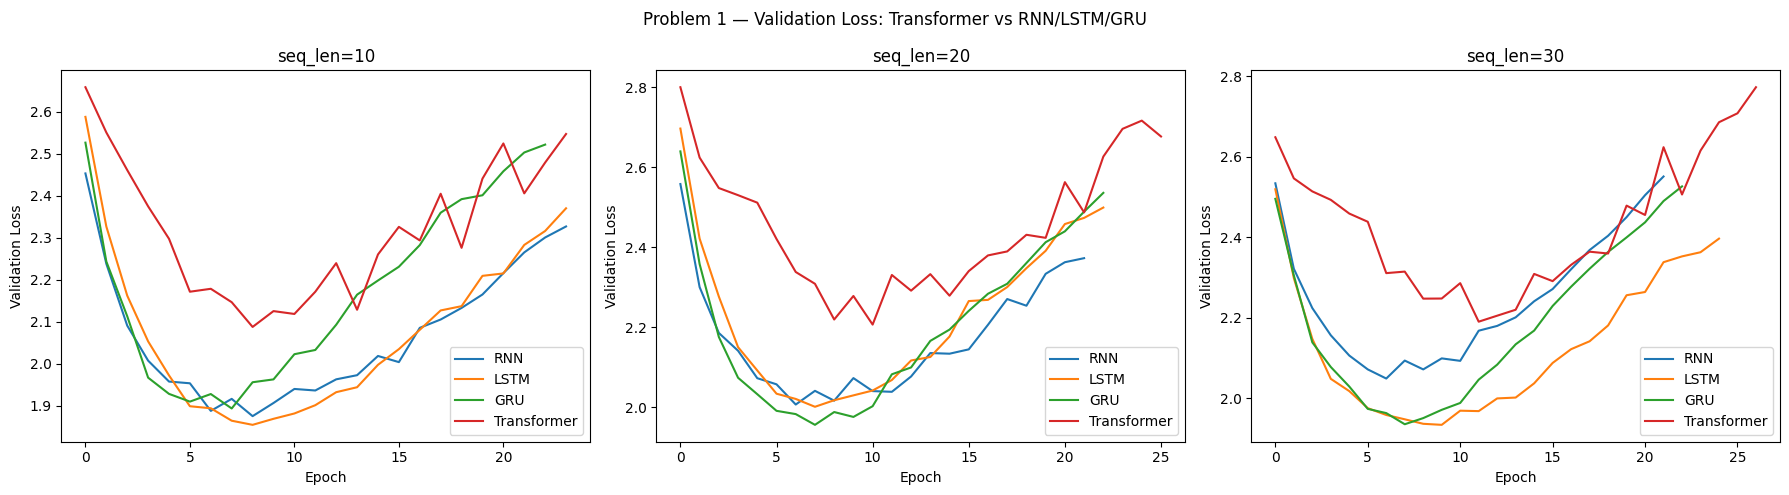

In [ ]:
# loss curve plots
fig, axes = plt.subplots(1, len(SEQ_LENGTHS_P1), figsize=(18, 5))
for ax, seq_len in zip(axes, SEQ_LENGTHS_P1):
    for r in [x for x in problem1_results if x["seq_len"] == seq_len]:
        ax.plot(r["val_losses"], label=r["model_name"])
    ax.set_title(f"seq_len={seq_len}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Loss")
    ax.legend()
fig.suptitle("Problem 1 — Validation Loss: Transformer vs RNN/LSTM/GRU")
plt.tight_layout()
plt.savefig("problem1_val_loss.png", dpi=150)
plt.show()

In [ ]:
def predict_next_char(model, char_to_ix, ix_to_char, initial_str, seq_len):
    model.eval()
    with torch.no_grad():
        initial_input = torch.tensor(
            [char_to_ix[c] for c in initial_str[-seq_len:]], dtype=torch.long
        ).unsqueeze(0).to(device)
        prediction = model(initial_input)
        predicted_idx = torch.argmax(prediction, dim=1).item()
        return ix_to_char[predicted_idx]


def generate_text(model, seed, seq_len, length=200):
    result = seed
    for _ in range(length):
        result += predict_next_char(model, char_to_int, int_to_char, result, seq_len)
    return result


SEED_TEXT = "Next character prediction "
print("=== Problem 1 — seq_len=30 generated continuations ===")
for r in [r for r in problem1_results if r["seq_len"] == 30]:
    print(f"\n-- {r['model_name']} --")
    print(generate_text(r["model"], SEED_TEXT, seq_len=30, length=150))

=== Problem 1 — seq_len=30 generated continuations ===

-- RNN --
Next character prediction the prediction the prediction the prediction the prediction the prediction the prediction the prediction the prediction the prediction the prediction 

-- LSTM --
Next character prediction the model for the model for the model for the model for the model for the model for the model for the model for the model for the model for the model 

-- GRU --
Next character prediction in the model for the model for the model for the model for the model for the model for the model for the model for the model for the model for the mod

-- Transformer --
Next character prediction ing ith churacter in in in the character in in in the character in in in the character in in in the character in in in the character in in in the char


Problem 2

In [ ]:
shakespeare_text = text

shk_chars = sorted(list(set(shakespeare_text)))
shk_vocab_size = len(shk_chars)
shk_char_to_int = {ch: i for i, ch in enumerate(shk_chars)}
shk_int_to_char = {i: ch for i, ch in enumerate(shk_chars)}
shk_encoded_text = [shk_char_to_int[ch] for ch in shakespeare_text]

print(f"Tiny Shakespeare length : {len(shakespeare_text):,} characters")
print(f"Vocabulary              : {shk_vocab_size} unique characters")



Tiny Shakespeare length : 1,115,394 characters
Vocabulary              : 65 unique characters


In [ ]:
# Problem 2a: baseline — 2 transformer blocks, 2 heads, seqlen 20/30
SEQ_LENGTHS_P2 = [20, 30]
EPOCHS_P2 = 60
PATIENCE_P2 = 8
RNN_TYPES_P2 = ["LSTM", "GRU"]

problem2_baseline_results = []
for seq_len in SEQ_LENGTHS_P2:
    for mtype in RNN_TYPES_P2:
        model = build_rnn_model(mtype, shk_vocab_size, hidden_size=TRANSFORMER_HIDDEN)
        r = train_char_model(model, mtype, shk_encoded_text, seq_len, epochs=EPOCHS_P2,
                              log_every=1, patience=PATIENCE_P2)
        problem2_baseline_results.append(r)

    transformer_model = CharTransformer(shk_vocab_size, TRANSFORMER_HIDDEN, n_layers=2, n_heads=2)
    r = train_char_model(
        transformer_model, "Transformer(2L,2H)", shk_encoded_text, seq_len, epochs=EPOCHS_P2,
        lr=0.001, log_every=1, patience=PATIENCE_P2
    )
    problem2_baseline_results.append(r)

print("\nProblem 2 baseline (seq_len 20/30) complete.")
print("=" * 115)
print("PROBLEM 2 — BASELINE RESULTS SUMMARY (2 blocks / 2 heads, best epoch)")
print("=" * 115)
print(f"{'Model':<20}{'SeqLen':>8}{'BestEp':>8}{'Ran':>6}{'Train Loss':>14}{'Val Loss':>12}{'Val Acc':>10}{'Time(s)':>10}{'Params':>12}")
print("-" * 115)
for r in problem2_baseline_results:
    print(
        f"{r['model_name']:<20}{r['seq_len']:>8}{r['best_epoch']:>8}{r['epochs_run']:>6}{r['best_train_loss']:>14.4f}"
        f"{r['best_val_loss']:>12.4f}{r['best_val_acc']:>10.4f}{r['train_time_s']:>10.1f}{r['n_params']:>12,}"
    )


=== LSTM | seq_len=20 (max_epochs=60, patience=8) ===
Epoch 1, Loss: 1.7558, Validation Loss: 1.6335, Validation Accuracy: 0.5136
Epoch 2, Loss: 1.5969, Validation Loss: 1.5888, Validation Accuracy: 0.5192
Epoch 3, Loss: 1.5613, Validation Loss: 1.5669, Validation Accuracy: 0.5295
Epoch 4, Loss: 1.5432, Validation Loss: 1.5612, Validation Accuracy: 0.5269
Epoch 5, Loss: 1.5336, Validation Loss: 1.5448, Validation Accuracy: 0.5336
Epoch 6, Loss: 1.5307, Validation Loss: 1.5527, Validation Accuracy: 0.5306
Epoch 7, Loss: 1.5297, Validation Loss: 1.5458, Validation Accuracy: 0.5315
Epoch 8, Loss: 1.5301, Validation Loss: 1.5609, Validation Accuracy: 0.5297
Epoch 9, Loss: 1.5300, Validation Loss: 1.5502, Validation Accuracy: 0.5307
Epoch 10, Loss: 1.5406, Validation Loss: 1.5784, Validation Accuracy: 0.5258
Epoch 11, Loss: 1.5456, Validation Loss: 1.5593, Validation Accuracy: 0.5284
Epoch 12, Loss: 1.5460, Validation Loss: 1.5690, Validation Accuracy: 0.5274
Epoch 13, Loss: 1.5506, Valida

In [ ]:
LAYER_OPTIONS = [1, 2, 4]
HEAD_OPTIONS = [2, 4]
SWEEP_SEQ_LEN = 30
EPOCHS_SWEEP = 35
PATIENCE_SWEEP = 8

problem2_sweep_results = []
for n_layers in LAYER_OPTIONS:
    for n_heads in HEAD_OPTIONS:
        model = CharTransformer(shk_vocab_size, TRANSFORMER_HIDDEN, n_layers=n_layers, n_heads=n_heads)
        name = f"Transformer({n_layers}L,{n_heads}H)"
        r = train_char_model(
            model, name, shk_encoded_text, SWEEP_SEQ_LEN, epochs=EPOCHS_SWEEP,
            lr=0.001, log_every=2, patience=PATIENCE_SWEEP
        )

        # perplexity
        r["perplexity"] = float(np.exp(r["best_val_loss"]))
        r["n_layers"] = n_layers
        r["n_heads"] = n_heads
        problem2_sweep_results.append(r)

print("\nProblem 2 hyperparameter sweep (8 configurations) complete.")

print("=" * 120)
print(f"PROBLEM 2 — 8-CONFIGURATION SWEEP (seq_len={SWEEP_SEQ_LEN}, best epoch)")
print("=" * 120)
print(f"{'Config':<20}{'BestEp':>8}{'Ran':>6}{'Train Loss':>14}{'Val Loss':>12}{'Val Acc':>10}{'Perplexity':>12}{'Time(s)':>10}{'Params':>12}")
print("-" * 120)
for r in problem2_sweep_results:
    print(
        f"{r['model_name']:<20}{r['best_epoch']:>8}{r['epochs_run']:>6}{r['best_train_loss']:>14.4f}{r['best_val_loss']:>12.4f}"
        f"{r['best_val_acc']:>10.4f}{r['perplexity']:>12.3f}{r['train_time_s']:>10.1f}{r['n_params']:>12,}"
    )

best_config = min(problem2_sweep_results, key=lambda r: r["best_val_loss"])
print(f"\nBest configuration by validation loss: {best_config['model_name']} "
      f"(best epoch={best_config['best_epoch']}, val loss={best_config['best_val_loss']:.4f}, "
      f"perplexity={best_config['perplexity']:.3f})")


=== Transformer(1L,2H) | seq_len=30 (max_epochs=35, patience=8) ===
Epoch 2, Loss: 1.7904, Validation Loss: 1.6845, Validation Accuracy: 0.4918
Epoch 4, Loss: 1.7057, Validation Loss: 1.6069, Validation Accuracy: 0.5107
Epoch 6, Loss: 1.6625, Validation Loss: 1.5692, Validation Accuracy: 0.5210
Epoch 8, Loss: 1.6312, Validation Loss: 1.5425, Validation Accuracy: 0.5288
Epoch 10, Loss: 1.6122, Validation Loss: 1.5183, Validation Accuracy: 0.5345
Epoch 12, Loss: 1.5948, Validation Loss: 1.5052, Validation Accuracy: 0.5388
Epoch 14, Loss: 1.5808, Validation Loss: 1.4946, Validation Accuracy: 0.5425
Epoch 16, Loss: 1.5706, Validation Loss: 1.4822, Validation Accuracy: 0.5466
Epoch 18, Loss: 1.5604, Validation Loss: 1.4778, Validation Accuracy: 0.5467
Epoch 20, Loss: 1.5530, Validation Loss: 1.4707, Validation Accuracy: 0.5489
Epoch 22, Loss: 1.5459, Validation Loss: 1.4660, Validation Accuracy: 0.5504
Epoch 24, Loss: 1.5399, Validation Loss: 1.4620, Validation Accuracy: 0.5507
Epoch 26, L

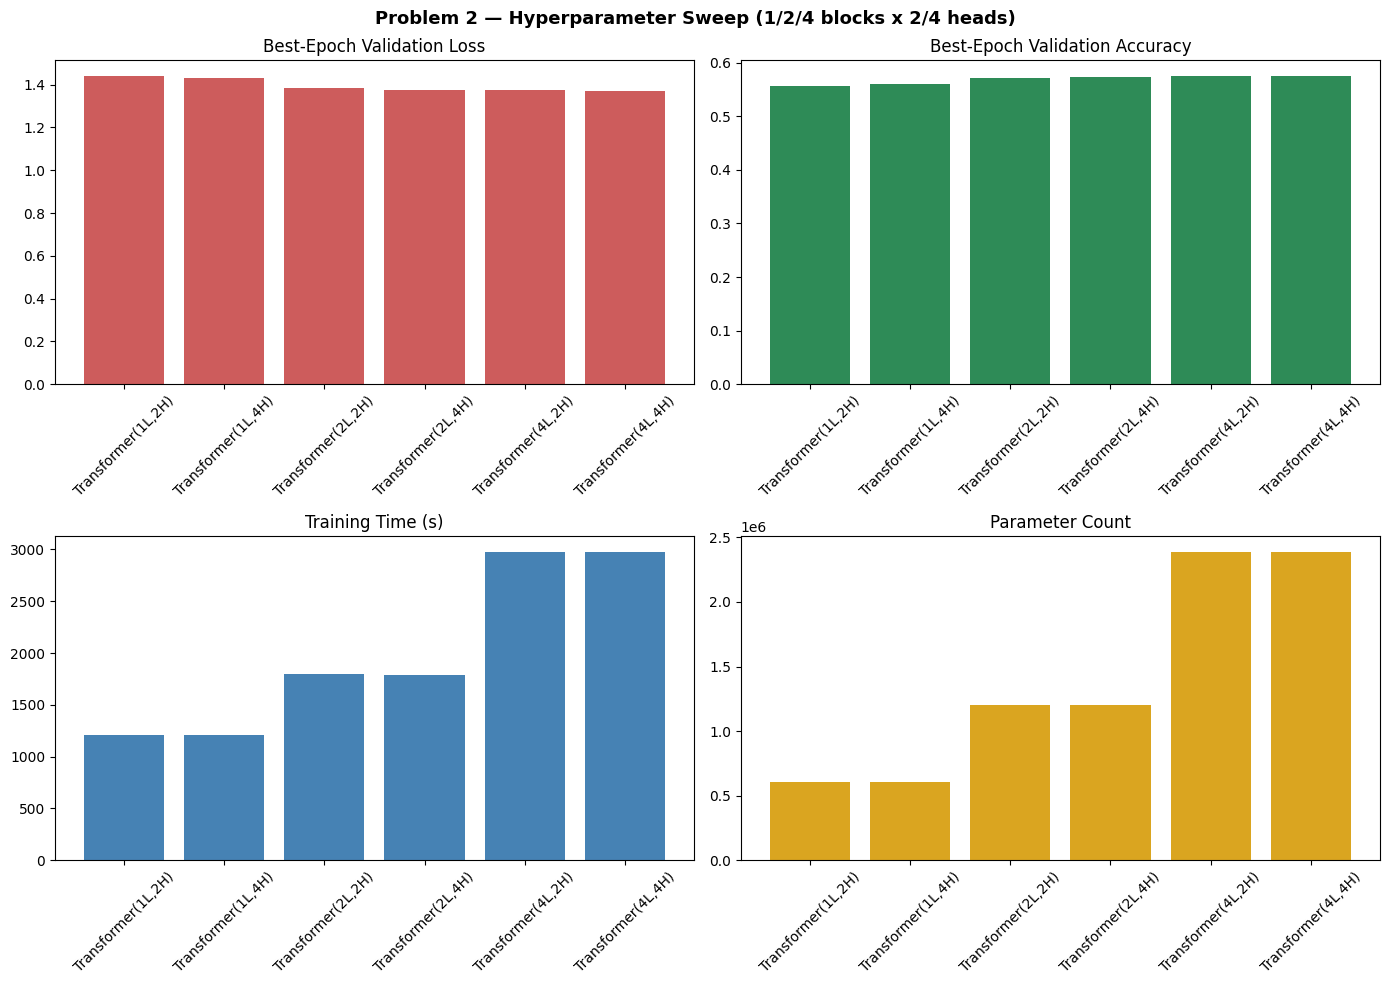

In [ ]:
#Problem 2b: bar charts across the 6 configs
labels = [r["model_name"] for r in problem2_sweep_results]
val_losses_bar = [r["best_val_loss"] for r in problem2_sweep_results]
val_accs_bar = [r["best_val_acc"] for r in problem2_sweep_results]
times_bar = [r["train_time_s"] for r in problem2_sweep_results]
params_bar = [r["n_params"] for r in problem2_sweep_results]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].bar(labels, val_losses_bar, color="indianred"); axes[0, 0].set_title("Best-Epoch Validation Loss"); axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 1].bar(labels, val_accs_bar, color="seagreen"); axes[0, 1].set_title("Best-Epoch Validation Accuracy"); axes[0, 1].tick_params(axis='x', rotation=45)
axes[1, 0].bar(labels, times_bar, color="steelblue"); axes[1, 0].set_title("Training Time (s)"); axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 1].bar(labels, params_bar, color="goldenrod"); axes[1, 1].set_title("Parameter Count"); axes[1, 1].tick_params(axis='x', rotation=45)
fig.suptitle("Problem 2 — Hyperparameter Sweep (1/2/4 blocks x 2/4 heads)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("problem2_sweep_bars.png", dpi=150)
plt.show()

In [ ]:
# Problem 2c sequence length to 50
EPOCHS_P2_LONG = 20
PATIENCE_P2_LONG = 8
model_50 = CharTransformer(
    shk_vocab_size, TRANSFORMER_HIDDEN,
    n_layers=TRANSFORMER_LAYERS_DEFAULT, n_heads=TRANSFORMER_HEADS_DEFAULT
)
problem2_seqlen50_result = train_char_model(
    model_50, "Transformer(2L,2H)", shk_encoded_text, seq_len=50, epochs=EPOCHS_P2_LONG,
    lr=0.001, log_every=1, patience=PATIENCE_P2_LONG
)
problem2_seqlen50_result["perplexity"] = float(np.exp(problem2_seqlen50_result["best_val_loss"]))

print("\n=== Problem 2 — seq_len=50 result (best epoch) ===")
print(f"Best Epoch: {problem2_seqlen50_result['best_epoch']}/{problem2_seqlen50_result['epochs_run']} | "
      f"Train Loss: {problem2_seqlen50_result['best_train_loss']:.4f} | "
      f"Val Loss: {problem2_seqlen50_result['best_val_loss']:.4f} | "
      f"Val Acc: {problem2_seqlen50_result['best_val_acc']:.4f} | "
      f"Perplexity: {problem2_seqlen50_result['perplexity']:.3f}")
print(f"Params: {problem2_seqlen50_result['n_params']:,} | "
      f"Size: {problem2_seqlen50_result['size_kb']:.1f} KB | "
      f"Time: {problem2_seqlen50_result['train_time_s']:.1f}s")


=== Transformer(2L,2H) | seq_len=50 (max_epochs=20, patience=8) ===
Epoch 1, Loss: 1.9178, Validation Loss: 1.6785, Validation Accuracy: 0.4946
Epoch 2, Loss: 1.6937, Validation Loss: 1.6037, Validation Accuracy: 0.5100
Epoch 3, Loss: 1.6305, Validation Loss: 1.5545, Validation Accuracy: 0.5241
Epoch 4, Loss: 1.5914, Validation Loss: 1.5294, Validation Accuracy: 0.5303
Epoch 5, Loss: 1.5632, Validation Loss: 1.5097, Validation Accuracy: 0.5362
Epoch 6, Loss: 1.5413, Validation Loss: 1.4955, Validation Accuracy: 0.5382
Epoch 7, Loss: 1.5241, Validation Loss: 1.4845, Validation Accuracy: 0.5420
Epoch 8, Loss: 1.5110, Validation Loss: 1.4637, Validation Accuracy: 0.5477
Epoch 9, Loss: 1.4983, Validation Loss: 1.4600, Validation Accuracy: 0.5502
Epoch 10, Loss: 1.4879, Validation Loss: 1.4514, Validation Accuracy: 0.5515
Epoch 11, Loss: 1.4791, Validation Loss: 1.4396, Validation Accuracy: 0.5543
Epoch 12, Loss: 1.4702, Validation Loss: 1.4353, Validation Accuracy: 0.5545
Epoch 13, Loss: 

In [ ]:
# Problem 2: qualitative generation
SHK_SEED = "ROMEO:\nWhat "
print("=== Problem 2 — seq_len=30 baseline generated text ===")
for r in [r for r in problem2_baseline_results if r["seq_len"] == 30]:
    print(f"\n-- {r['model_name']} --")
    text_out = SHK_SEED
    for _ in range(150):
        text_out += predict_next_char(r["model"], shk_char_to_int, shk_int_to_char, text_out, seq_len=30)
    print(text_out)

print("\n=== Problem 2 — seq_len=50 Transformer generated text ===")
text_out = SHK_SEED
for _ in range(150):
    text_out += predict_next_char(model_50, shk_char_to_int, shk_int_to_char, text_out, seq_len=50)
print(text_out)

=== Problem 2 — seq_len=30 baseline generated text ===

-- LSTM --
ROMEO:
What is the will the will the dead,
The will the will the will the dead,
The will the will the will the dead,
The will the will the will the dead,
The will

-- GRU --
ROMEO:
What the dantage the dantage the daurted
And the dantage the dantage the daurted
And the dantage the dantage the daurted
And the dantage the dantage the da

-- Transformer(2L,2H) --
ROMEO:
What ,,,,,,XXX,!!! m talk you shall be so much a services the sent the seat the sent the seat the sent the seat the sent the seat the sent the seat the sen

=== Problem 2 — seq_len=50 Transformer generated text ===
ROMEO:
What s,,,s,
s y, y, y, y, y, y, y, y, se to the sear the seas the seas the sea,
the seat thou shall be the seas the seas the sea,
And the shall be the seas
